## Laufzeiten der Sortieralgorithmen

Sortieralgorithmen mit quadratischer Laufzeit

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import random
import time 

#### Aufgabe:

In der nächsten Zelle wird die durchschnittliche Laufzeit für die Sortierung gemessen. Lasse für jeden der drei Sortieralgorithmen die Zelle für N=1,2,4,8,16,32 laufen und trage die Werte in der übernächsten Zelle ein. Bei großem N muss ggf. die Anzahl der Versuche für die Durchschnittsbildung reduziert werden, damit die Berechnung nicht zu lange dauert.


In [2]:
def selection_sort(a):
    for i in range(len(a)-1):
        best = i
        best_val = a[i]
        for j in range(i+1,len(a)):
            if a[j] < best_val:
                best = j
                best_val = a[j]
        a[best],a[i] = a[i],a[best]

def bubble_sort(a):
    getauscht = True
    while getauscht:
        getauscht = False
        for i in range(len(a)-1):
            if a[i] > a[i+1]:
                a[i],a[i+1]=a[i+1],a[i]
                getauscht = True

def insertion_sort(a):
    for i in range(1,len(a)):
        x = a[i]
        j = i
        while j > 0 and a[j-1] > x:
            a[j] = a[j-1]
            j = j - 1
        a[j] = x

In [8]:
N = 1                         # Anzahl zu sortierender Elemente in Tausend
anzahl_versuche = 20          # Anzahl Sortiervorgänge für die Durchschnittsbildung
summe = 0
for i in range(anzahl_versuche):
    a = [random.randint(-N*1000,N*1000) for _  in range(N*1000)]    # Liste mit Zufallszahlen
    start = time.perf_counter()
    selection_sort(a)         # <------------- update: Sortieralgorithmus 
    end = time.perf_counter()
    summe = summe + (end-start)
print(f'{summe/anzahl_versuche:.3f}')    # Durchschnittliche Laufzeit in Sekunden


0.029


In [9]:
anzahl = [1, 2, 4, 8, 16, 32]                       # Anzahl zu sortierender Elemente in Tausend
selection = [1.06, 1.26, 2.02, 5.1, 17.38, 66.54]   # update  Zeit in Sekunden
bubble =    [1.06, 1.26, 2.02, 5.1, 17.38, 66.54]   # update
insertion= [1.06, 1.26, 2.02, 5.1, 17.38, 66.54]    # update

In [10]:
def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c

params, _ = curve_fit(quadratic_model, anzahl, selection)
a_selection, b_selection, c_selection = params
print(f"selection: f(x) ≈ {a_selection:.8f} * x**2 + {b_selection:.8f} * x + {c_selection}") 
params, _ = curve_fit(quadratic_model, anzahl, bubble)
a_bubble, b_bubble, c_bubble = params
print(f"bubble   : f(x) ≈ {a_bubble:.8f} * x**2 + {b_bubble:.8f} * x + {c_bubble}") 
params, _ = curve_fit(quadratic_model, anzahl, bubble)
a_insertion, b_insertion, c_insertion = params
print(f"insertion: f(x) ≈ {a_insertion:.8f} * x**2 + {b_insertion:.8f} * x + {c_insertion}") 

selection: f(x) ≈ 0.06401067 * x**2 + -0.00023114 * x + 1.000000000000069
bubble   : f(x) ≈ 0.06401067 * x**2 + -0.00023114 * x + 1.000000000000069
insertion: f(x) ≈ 0.06401067 * x**2 + -0.00023114 * x + 1.000000000000069


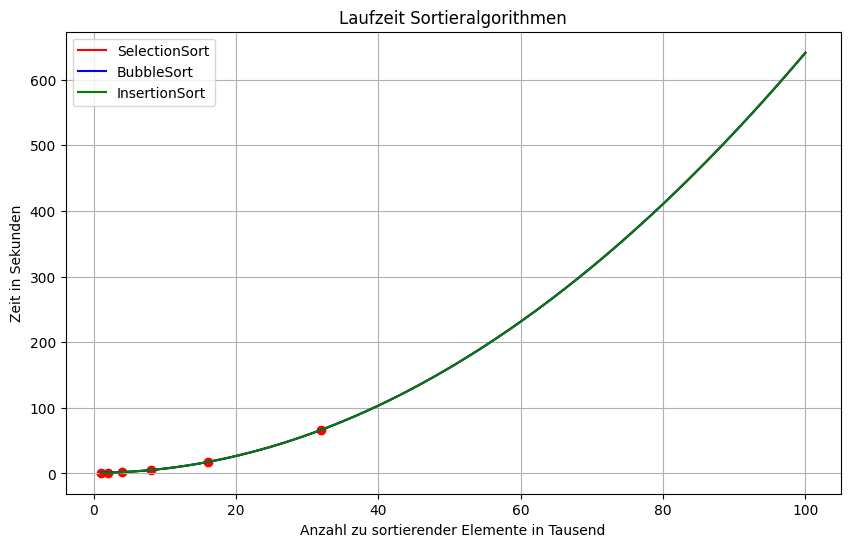

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(anzahl, selection, color='red')
# plt.scatter(anzahl, bubble, color='blue')
# plt.scatter(anzahl, insertion, color='green')
xs = np.linspace(1,100,200)
plt.plot(xs, quadratic_model(xs, a_selection, b_selection, c_selection), label="SelectionSort", color='red')
plt.plot(xs, quadratic_model(xs, a_selection, b_selection, c_selection), label="BubbleSort", color='blue')
plt.plot(xs, quadratic_model(xs, a_selection, b_selection, c_selection), label="InsertionSort", color='green')
plt.xlabel("Anzahl zu sortierender Elemente in Tausend")
plt.ylabel("Zeit in Sekunden")
plt.title("Laufzeit Sortieralgorithmen")
plt.legend()
plt.grid(True)
plt.show()
